
# Lite Trend Forecast Notebook (No Overengineering)

Tujuan notebook ini: **melihat trend 5 bulan ke depan** dengan pipeline sederhana dan stabil.

Prinsip:
1. Data pendek (19 bulan) -> model sederhana lebih aman.
2. Fokus near-term trend -> bobot evaluasi lebih besar ke operational window.
3. Hindari feature/model kompleks yang rawan overfit.

Output:
- `submission_mepa_lite_trend.csv`
- `forecast_details_mepa_lite_trend.json`


In [1]:

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.optimize import minimize
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'monthly_timeseries.csv'
OUT_SUBMISSION = BASE_DIR / 'submission_mepa_lite_trend.csv'
OUT_DETAILS = BASE_DIR / 'forecast_details_mepa_lite_trend.json'

FORECAST_HORIZON = 5
FORECAST_MONTHS = pd.date_range('2025-08-01', periods=FORECAST_HORIZON, freq='MS')

monthly = pd.read_csv(DATA_PATH)
monthly['Bulan'] = pd.to_datetime(monthly['Bulan'])
monthly = monthly.set_index('Bulan').sort_index()

print('Data points:', len(monthly))
print('Range:', monthly.index.min().date(), 'to', monthly.index.max().date())
monthly.head()


Data points: 19
Range: 2024-01-01 to 2025-07-01


,Claim_Frequency,Claim_Severity,Total_Claim,pct_age_60plus,avg_age,pct_male,pct_cancer,pct_cardio,pct_renal,pct_overseas,...,std_nominal,pct_outlier,unique_polis,avg_claims_per_polis,Avg_Kurs_MYR,Avg_Kurs_SGD,MYR_change_pct,SGD_change_pct,log_Severity,log_Total
Bulan,,,,,,,,,,,,,,,,,,,,,
2024-01-01,296,6.752609e+07,1.998772e+10,0.493243,59.141892,0.533784,0.199324,0.121622,0.118243,0.310811,...,1.502107e+08,0.138514,174,1.701149,3322.580000,11684.268261,0.000000,0.000000,18.028025,23.718384
2024-02-01,208,6.663291e+07,1.385965e+10,0.475962,58.225962,0.572115,0.197115,0.091346,0.139423,0.326923,...,1.592391e+08,0.139423,120,1.733333,3278.814286,11628.560952,-1.317221,-0.476772,18.014709,23.352247
2024-03-01,278,5.147935e+07,1.431126e+10,0.474820,57.410072,0.453237,0.205036,0.097122,0.118705,0.338129,...,9.667738e+07,0.107914,174,1.597701,3327.047619,11708.249048,1.471060,0.685279,17.756691,23.384312
2024-04-01,236,4.846379e+07,1.143745e+10,0.377119,56.440678,0.500000,0.211864,0.072034,0.118644,0.309322,...,1.053562e+08,0.110169,138,1.710145,3363.022727,11814.276364,1.081292,0.905578,17.696327,23.160159
2024-05-01,262,4.654319e+07,1.219432e+10,0.404580,56.755725,0.503817,0.209924,0.083969,0.129771,0.286260,...,1.216351e+08,0.072519,152,1.723684,3404.199130,11888.559130,1.224387,0.628754,17.655891,23.224236


## 1) Metrics

In [2]:

def mepa(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / den)) * 100)


def mdape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.maximum(np.abs(y_true), eps)
    return float(np.median(np.abs((y_true - y_pred) / den)) * 100)


def evaluate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MEPA': mepa(y_true, y_pred),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MdAPE': mdape(y_true, y_pred),
    }


## 2) Simple Model Pool

In [3]:

TARGETS = {
    'Claim_Frequency': {'use_log': False},
    'Claim_Severity': {'use_log': True},
    'Total_Claim': {'use_log': True},
}

MODELS = ['naive', 'seasonal_naive', 'ma3', 'ets']


def pred_1step(model_name, series, use_log):
    y = series.astype(float)

    if model_name == 'naive':
        return float(y.iloc[-1])

    if model_name == 'seasonal_naive':
        if len(y) >= 12:
            return float(y.iloc[-12])
        if len(y) >= 6:
            return float(y.iloc[-6])
        return float(y.iloc[-1])

    if model_name == 'ma3':
        return float(y.tail(min(3, len(y))).mean())

    if model_name == 'ets':
        if use_log:
            m = ExponentialSmoothing(np.log1p(y), trend='add', damped_trend=True, seasonal=None).fit(optimized=True)
            return float(np.expm1(m.forecast(1).iloc[0]))
        m = ExponentialSmoothing(y, trend='add', damped_trend=True, seasonal=None).fit(optimized=True)
        return float(m.forecast(1).iloc[0])

    raise ValueError(model_name)


def backtest_target(target, n_test, min_train=8):
    use_log = TARGETS[target]['use_log']
    s = monthly[target].dropna().astype(float)
    start = max(min_train, len(s) - n_test)

    y_true = []
    preds = {m: [] for m in MODELS}

    for i in range(start, len(s)):
        tr = s.iloc[:i]
        te = float(s.iloc[i])
        y_true.append(te)

        for m in MODELS:
            try:
                p = pred_1step(m, tr, use_log)
            except Exception:
                p = float(tr.iloc[-1])
            preds[m].append(max(0.0, float(p)))

    return {
        'y_true': np.asarray(y_true, dtype=float),
        'preds': {k: np.asarray(v, dtype=float) for k, v in preds.items()}
    }


## 3) Weight Optimization (Trend-Focused)

In [4]:

WINDOWS = {'strict': 7, 'operational': 3}
STRICT_WEIGHT = 0.30  # trend near-term -> lebih berat ke operational

opt = {}

for t in TARGETS:
    bt = {w: backtest_target(t, n_test=n) for w, n in WINDOWS.items()}

    rank = []
    for m in MODELS:
        row = {'model': m}
        for w in WINDOWS:
            y = bt[w]['y_true']
            p = bt[w]['preds'][m]
            row[f'MEPA_{w}'] = mepa(y, p)
            row[f'MAE_{w}'] = mean_absolute_error(y, p)
        rank.append(row)

    rank_df = pd.DataFrame(rank).sort_values('MEPA_operational').reset_index(drop=True)

    Ys = bt['strict']['y_true']
    Yo = bt['operational']['y_true']
    Ps = np.column_stack([bt['strict']['preds'][m] for m in MODELS])
    Po = np.column_stack([bt['operational']['preds'][m] for m in MODELS])

    def obj_w(w):
        ps = Ps.dot(w)
        po = Po.dot(w)
        return STRICT_WEIGHT * mepa(Ys, ps) + (1 - STRICT_WEIGHT) * mepa(Yo, po)

    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
    bnds = [(0.0, 1.0)] * len(MODELS)
    x0 = np.ones(len(MODELS)) / len(MODELS)

    res_w = minimize(obj_w, x0=x0, method='SLSQP', bounds=bnds, constraints=cons)
    w_opt = res_w.x if res_w.success else x0

    def obj_ab(v):
        a, b = v
        ps = np.maximum(0.0, a * Ps.dot(w_opt) + b)
        po = np.maximum(0.0, a * Po.dot(w_opt) + b)
        return STRICT_WEIGHT * mepa(Ys, ps) + (1 - STRICT_WEIGHT) * mepa(Yo, po)

    mean_ref = float(np.mean(Yo))
    res_ab = minimize(
        obj_ab,
        x0=np.array([1.0, 0.0]),
        bounds=[(0.85, 1.15), (-0.12 * mean_ref, 0.12 * mean_ref)],
        method='L-BFGS-B'
    )

    a_opt, b_opt = (res_ab.x if res_ab.success else [1.0, 0.0])

    metrics = {}
    for w in WINDOWS:
        y = bt[w]['y_true']
        P = np.column_stack([bt[w]['preds'][m] for m in MODELS])
        raw = P.dot(w_opt)
        cal = np.maximum(0.0, a_opt * raw + b_opt)
        metrics[w] = {'raw': evaluate_metrics(y, raw), 'cal': evaluate_metrics(y, cal)}

    opt[t] = {
        'weights': w_opt,
        'a': float(a_opt),
        'b': float(b_opt),
        'metrics': metrics,
        'rank_df': rank_df,
        'bt': bt,
    }

    print(f'\n=== {t} ===')
    display(rank_df)
    print('weights:', dict(zip(MODELS, np.round(w_opt, 4))))
    print('strict MEPA:', round(metrics['strict']['cal']['MEPA'], 4), '| operational MEPA:', round(metrics['operational']['cal']['MEPA'], 4))



=== Claim_Frequency ===


,model,MEPA_strict,MAE_strict,MEPA_operational,MAE_operational
0,seasonal_naive,14.935525,33.857143,5.911126,14.333333
1,ets,7.165760,16.572231,6.056408,15.447583
2,ma3,8.157380,18.809524,7.392972,18.777778
3,naive,9.483550,22.285714,8.823700,22.000000


weights: {'naive': np.float64(0.0), 'seasonal_naive': np.float64(0.3837), 'ma3': np.float64(0.0), 'ets': np.float64(0.6163)}
strict MEPA: 9.092 | operational MEPA: 3.539

=== Claim_Severity ===


,model,MEPA_strict,MAE_strict,MEPA_operational,MAE_operational
0,ets,10.277592,6.220418e+06,4.462824,2.447019e+06
1,naive,15.237594,9.100673e+06,8.512590,4.589051e+06
2,seasonal_naive,15.449838,7.838067e+06,8.999702,4.733529e+06
3,ma3,12.296602,7.241602e+06,9.414872,4.909586e+06


weights: {'naive': np.float64(0.0455), 'seasonal_naive': np.float64(0.2731), 'ma3': np.float64(0.0), 'ets': np.float64(0.6814)}
strict MEPA: 10.818 | operational MEPA: 4.2439

=== Total_Claim ===


,model,MEPA_strict,MAE_strict,MEPA_operational,MAE_operational
0,ets,14.298657,1.938784e+09,6.250424,8.456553e+08
1,seasonal_naive,22.088782,2.493240e+09,6.286549,8.497406e+08
2,naive,19.998685,2.732137e+09,6.547548,8.449927e+08
3,ma3,17.976203,2.329420e+09,11.176813,1.447359e+09


weights: {'naive': np.float64(0.0689), 'seasonal_naive': np.float64(0.4932), 'ma3': np.float64(0.0402), 'ets': np.float64(0.3978)}
strict MEPA: 15.972 | operational MEPA: 2.961


## 4) Forecast 5 Months

In [5]:

def forecast_model_path(model_name, series, horizon, use_log):
    y = series.astype(float)

    if model_name == 'naive':
        return np.repeat(float(y.iloc[-1]), horizon)

    if model_name == 'seasonal_naive':
        if len(y) >= 12:
            return np.repeat(float(y.iloc[-12]), horizon)
        if len(y) >= 6:
            return np.repeat(float(y.iloc[-6]), horizon)
        return np.repeat(float(y.iloc[-1]), horizon)

    if model_name == 'ma3':
        return np.repeat(float(y.tail(min(3, len(y))).mean()), horizon)

    if model_name == 'ets':
        if use_log:
            m = ExponentialSmoothing(np.log1p(y), trend='add', damped_trend=True, seasonal=None).fit(optimized=True)
            return np.maximum(np.expm1(m.forecast(horizon).values), 0.0)
        m = ExponentialSmoothing(y, trend='add', damped_trend=True, seasonal=None).fit(optimized=True)
        return np.maximum(m.forecast(horizon).values, 0.0)

    raise ValueError(model_name)


fc = {}
for t in TARGETS:
    use_log = TARGETS[t]['use_log']
    s = monthly[t].astype(float)

    each = {m: forecast_model_path(m, s, FORECAST_HORIZON, use_log) for m in MODELS}
    M = np.column_stack([each[m] for m in MODELS])

    raw = M.dot(opt[t]['weights'])
    cal = np.maximum(0.0, opt[t]['a'] * raw + opt[t]['b'])

    if t == 'Claim_Frequency':
        cal = np.round(cal).astype(int)

    fc[t] = {'per_model': each, 'raw': raw, 'cal': cal}

# Konsistensi total: blend direct vs derived

derived_total = fc['Claim_Frequency']['cal'] * fc['Claim_Severity']['cal']
direct_total = fc['Total_Claim']['cal']

# optimize alpha pakai gabungan strict+operational
Ys = opt['Total_Claim']['bt']['strict']['y_true']
Yo = opt['Total_Claim']['bt']['operational']['y_true']
P_s = np.column_stack([opt['Total_Claim']['bt']['strict']['preds'][m] for m in MODELS])
P_o = np.column_stack([opt['Total_Claim']['bt']['operational']['preds'][m] for m in MODELS])

dir_s = np.maximum(0.0, opt['Total_Claim']['a'] * P_s.dot(opt['Total_Claim']['weights']) + opt['Total_Claim']['b'])
dir_o = np.maximum(0.0, opt['Total_Claim']['a'] * P_o.dot(opt['Total_Claim']['weights']) + opt['Total_Claim']['b'])

Pf_s = np.column_stack([opt['Claim_Frequency']['bt']['strict']['preds'][m] for m in MODELS])
Ps_s = np.column_stack([opt['Claim_Severity']['bt']['strict']['preds'][m] for m in MODELS])
Pf_o = np.column_stack([opt['Claim_Frequency']['bt']['operational']['preds'][m] for m in MODELS])
Ps_o = np.column_stack([opt['Claim_Severity']['bt']['operational']['preds'][m] for m in MODELS])

f_s = np.maximum(0.0, opt['Claim_Frequency']['a'] * Pf_s.dot(opt['Claim_Frequency']['weights']) + opt['Claim_Frequency']['b'])
s_s = np.maximum(0.0, opt['Claim_Severity']['a'] * Ps_s.dot(opt['Claim_Severity']['weights']) + opt['Claim_Severity']['b'])
f_o = np.maximum(0.0, opt['Claim_Frequency']['a'] * Pf_o.dot(opt['Claim_Frequency']['weights']) + opt['Claim_Frequency']['b'])
s_o = np.maximum(0.0, opt['Claim_Severity']['a'] * Ps_o.dot(opt['Claim_Severity']['weights']) + opt['Claim_Severity']['b'])

der_s = f_s * s_s
der_o = f_o * s_o

alpha_grid = np.linspace(0, 1, 41)
alpha_scores = [
    (
        a,
        STRICT_WEIGHT * mepa(Ys, a * dir_s + (1 - a) * der_s)
        + (1 - STRICT_WEIGHT) * mepa(Yo, a * dir_o + (1 - a) * der_o)
    )
    for a in alpha_grid
]
alpha_opt, alpha_obj = sorted(alpha_scores, key=lambda x: x[1])[0]

total_final = alpha_opt * direct_total + (1 - alpha_opt) * derived_total

forecast_df = pd.DataFrame({
    'Bulan': FORECAST_MONTHS,
    'Claim_Frequency': fc['Claim_Frequency']['cal'],
    'Claim_Severity': fc['Claim_Severity']['cal'],
    'Total_Claim_Direct': direct_total,
    'Total_Claim_Derived': derived_total,
    'Total_Claim_Final': total_final,
})

print('alpha_opt:', round(float(alpha_opt), 2), '| objective:', round(float(alpha_obj), 4))
display(forecast_df)


alpha_opt: 1.0 | objective: 6.8643


,Bulan,Claim_Frequency,Claim_Severity,Total_Claim_Direct,Total_Claim_Derived,Total_Claim_Final
0,2025-08-01,233,5.457989e+07,1.308226e+10,1.271711e+10,1.308226e+10
1,2025-09-01,233,5.456538e+07,1.307874e+10,1.271373e+10,1.307874e+10
2,2025-10-01,233,5.455377e+07,1.307592e+10,1.271103e+10,1.307592e+10
3,2025-11-01,233,5.454449e+07,1.307367e+10,1.270887e+10,1.307367e+10
4,2025-12-01,233,5.453706e+07,1.307187e+10,1.270714e+10,1.307187e+10


## 5) Save Outputs

In [6]:

# submission rows
rows = []
month_labels = [d.strftime('%Y_%m') for d in FORECAST_MONTHS]
for i, m in enumerate(month_labels):
    rows.append({'id': f'{m}_Claim_Frequency', 'value': float(forecast_df.loc[i, 'Claim_Frequency'])})
    rows.append({'id': f'{m}_Claim_Severity', 'value': float(forecast_df.loc[i, 'Claim_Severity'])})
    rows.append({'id': f'{m}_Total_Claim', 'value': float(forecast_df.loc[i, 'Total_Claim_Final'])})

submission = pd.DataFrame(rows)
submission.to_csv(OUT_SUBMISSION, index=False)

# confidence interval from operational APE
ci_pack = {}
for t in TARGETS:
    y = opt[t]['bt']['operational']['y_true']
    P = np.column_stack([opt[t]['bt']['operational']['preds'][m] for m in MODELS])
    p = np.maximum(0.0, opt[t]['a'] * P.dot(opt[t]['weights']) + opt[t]['b'])

    ape = np.abs((y - p) / np.maximum(np.abs(y), 1e-9))
    q80 = float(np.quantile(ape, 0.80))
    q95 = float(np.quantile(ape, 0.95))

    fut = np.asarray(fc[t]['cal'], dtype=float)
    ci80 = np.column_stack([np.maximum(fut * (1 - q80), 0.0), fut * (1 + q80)])
    ci95 = np.column_stack([np.maximum(fut * (1 - q95), 0.0), fut * (1 + q95)])

    ci_pack[t] = {
        'ci80': ci80.tolist(),
        'ci95': ci95.tolist(),
        'q80_ape': q80,
        'q95_ape': q95,
    }

summary_check = pd.DataFrame([
    {
        'target': t,
        'strict_mepa_cal': opt[t]['metrics']['strict']['cal']['MEPA'],
        'operational_mepa_cal': opt[t]['metrics']['operational']['cal']['MEPA'],
    }
    for t in TARGETS
])

details = {
    'approach': 'lite_trend_only',
    'data_points': int(len(monthly)),
    'forecast_months': [d.strftime('%Y-%m') for d in FORECAST_MONTHS],
    'models': MODELS,
    'windows': WINDOWS,
    'strict_weight': STRICT_WEIGHT,
    'targets': {},
    'total_blend': {'alpha_opt': float(alpha_opt), 'objective': float(alpha_obj)},
    'forecast': forecast_df.assign(Bulan=forecast_df['Bulan'].dt.strftime('%Y-%m')).to_dict(orient='records'),
    'confidence_intervals': ci_pack,
}

for t in TARGETS:
    details['targets'][t] = {
        'weights': {m: float(w) for m, w in zip(MODELS, opt[t]['weights'])},
        'calibration': {'a': float(opt[t]['a']), 'b': float(opt[t]['b'])},
        'strict': opt[t]['metrics']['strict'],
        'operational': opt[t]['metrics']['operational'],
        'ranking': opt[t]['rank_df'].to_dict(orient='records'),
    }

with open(OUT_DETAILS, 'w', encoding='utf-8') as f:
    json.dump(details, f, indent=2)

print('Saved:', OUT_SUBMISSION)
print('Saved:', OUT_DETAILS)
display(submission)
display(summary_check)


Saved: /home/data/kuliah/EDA/mcfitb/submission_mepa_lite_trend.csv
Saved: /home/data/kuliah/EDA/mcfitb/forecast_details_mepa_lite_trend.json


,id,value
0,2025_08_Claim_Frequency,2.330000e+02
1,2025_08_Claim_Severity,5.457989e+07
2,2025_08_Total_Claim,1.308226e+10
3,2025_09_Claim_Frequency,2.330000e+02
4,2025_09_Claim_Severity,5.456538e+07
5,2025_09_Total_Claim,1.307874e+10
6,2025_10_Claim_Frequency,2.330000e+02
7,2025_10_Claim_Severity,5.455377e+07
8,2025_10_Total_Claim,1.307592e+10
9,2025_11_Claim_Frequency,2.330000e+02


,target,strict_mepa_cal,operational_mepa_cal
0,Claim_Frequency,9.092014,3.538992
1,Claim_Severity,10.817958,4.243904
2,Total_Claim,15.972037,2.961017


## 6) Trend Plot

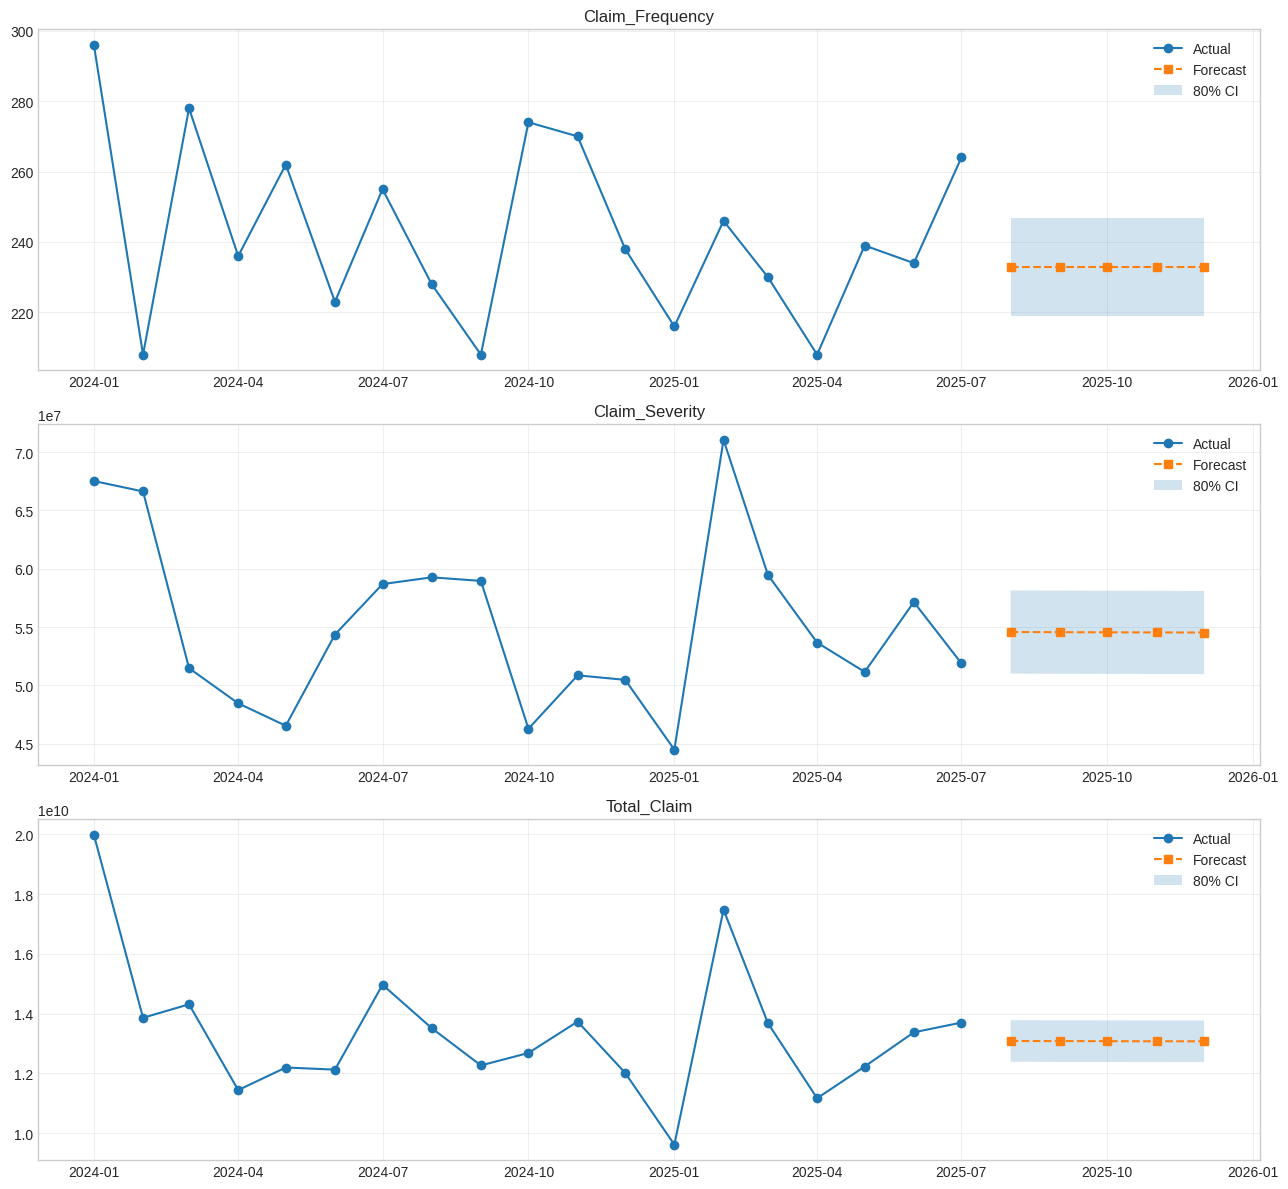

In [7]:

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

series_map = {
    'Claim_Frequency': 'Claim_Frequency',
    'Claim_Severity': 'Claim_Severity',
    'Total_Claim': 'Total_Claim_Final',
}

for ax, (hist_col, fc_col) in zip(axes, series_map.items()):
    ax.plot(monthly.index, monthly[hist_col], marker='o', label='Actual')
    ax.plot(FORECAST_MONTHS, forecast_df[fc_col], marker='s', linestyle='--', label='Forecast')

    ci80 = np.array(ci_pack[hist_col]['ci80'])
    ax.fill_between(FORECAST_MONTHS, ci80[:,0], ci80[:,1], alpha=0.2, label='80% CI')

    ax.set_title(hist_col)
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()
